In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

In [2]:
# Download dataset
path = kagglehub.dataset_download("solonofathens/10000-rows-randomly-sampled-from-lcallcsv")
files = os.listdir(path) if ( os := __import__('os') ).path.exists(path) else []
full_file_path = os.path.join(path, files[0]) if files else path

df = pd.read_csv(full_file_path)

Using Colab cache for faster access to the '10000-rows-randomly-sampled-from-lcallcsv' dataset.


In [3]:
print("=== STEP 1: UNDERSTAND YOUR DATA ===")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

=== STEP 1: UNDERSTAND YOUR DATA ===
Dataset shape: (1000, 141)

Column names:
['Unnamed: 0', 'X', 'id', 'load_entry_id', 'file_descriptor', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_join

In [4]:
print("\n=== STEP 2: HANDLE MISSING VALUES ===")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nMissing percentage:\n{(df.isnull().sum() / len(df) * 100).round(2)}")



=== STEP 2: HANDLE MISSING VALUES ===

Missing values per column:
Unnamed: 0                                       0
X                                                0
id                                               0
load_entry_id                                    0
file_descriptor                                  0
                                              ... 
hardship_dpd                                  1000
hardship_loan_status                          1000
orig_projected_additional_accrued_interest    1000
hardship_payoff_balance_amount                1000
hardship_last_payment_amount                  1000
Length: 141, dtype: int64

Missing percentage:
Unnamed: 0                                      0.0
X                                               0.0
id                                              0.0
load_entry_id                                   0.0
file_descriptor                                 0.0
                                              ...  
hardship_dpd 

In [5]:
print("\n=== STEP 3: DETECT AND HANDLE OUTLIERS ===")
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols[:3]:  # Check first 3 numerical columns
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    print(f"{col}: {len(outliers)} outliers ({(len(outliers)/len(df)*100):.1f}%)")


=== STEP 3: DETECT AND HANDLE OUTLIERS ===
Unnamed: 0: 0 outliers (0.0%)
X: 0 outliers (0.0%)
id: 0 outliers (0.0%)


In [6]:
print("\n=== STEP 4: ENCODE CATEGORICAL VARIABLES ===")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

for col in categorical_cols[:3]:  # Show first 3
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} unique values")
    if unique_vals <= 10:
        print(f"  Values: {df[col].unique()[:10].tolist()}")



=== STEP 4: ENCODE CATEGORICAL VARIABLES ===
Categorical columns: ['file_descriptor', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 'revol_util', 'initial_list_status', 'last_pymnt_d', 'last_credit_pull_d', 'application_type', 'verification_status_joint', 'hardship_flag']
file_descriptor: 10 unique values
  Values: ['3c', '3d', '2016Q3', '3b', '2016Q2', '2016Q4', '2017Q2', '2016Q1', '2017Q1', '2017Q3']
term: 2 unique values
  Values: ['36 months', '60 months']
int_rate: 200 unique values


In [7]:
print("\n=== STEP 5: EDA - EXPLORATORY DATA ANALYSIS ===")

# Describe numerical data
print(f"\nNumerical summary:\n{df.describe()}")

# Check class distribution (if target exists)
if 'target' in df.columns or 'label' in df.columns:
    target_col = 'target' if 'target' in df.columns else 'label'
    print(f"\nTarget distribution:\n{df[target_col].value_counts()}")



=== STEP 5: EDA - EXPLORATORY DATA ANALYSIS ===

Numerical summary:
          Unnamed: 0              X            id  load_entry_id  member_id  \
count    1000.000000    1000.000000  1.000000e+03   1.000000e+03        0.0   
mean   370706.792000  370706.792000  3.605385e+06  -2.140142e+09        NaN   
std    216560.821123  216560.821123  3.718515e+05   1.763403e+00        NaN   
min      2243.000000    2243.000000  3.093924e+06  -2.140142e+09        NaN   
25%    176136.750000  176136.750000  3.289652e+06  -2.140142e+09        NaN   
50%    371380.000000  371380.000000  3.507688e+06  -2.140142e+09        NaN   
75%    562971.750000  562971.750000  3.882713e+06  -2.140142e+09        NaN   
max    744419.000000  744419.000000  4.688187e+06  -2.140142e+09        NaN   

          loan_amnt   funded_amnt  funded_amnt_inv  installment  \
count   1000.000000   1000.000000      1000.000000  1000.000000   
mean   14167.300000  14167.300000     14160.850000   436.991270   
std     8388.77052


=== STEP 6: VISUALIZATIONS ===
Saved: eda_numerical_distributions.png
Saved: correlation_heatmap.png


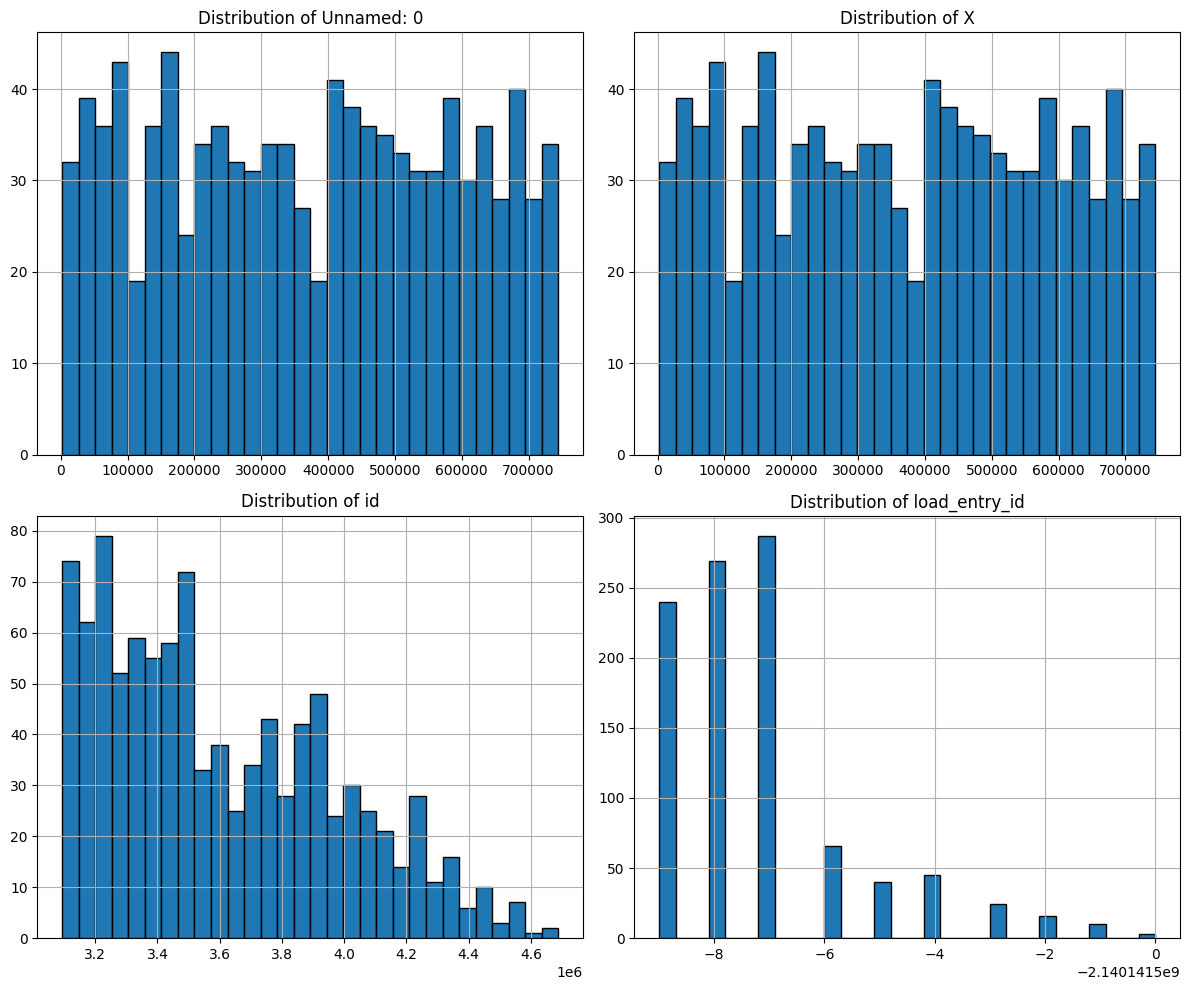

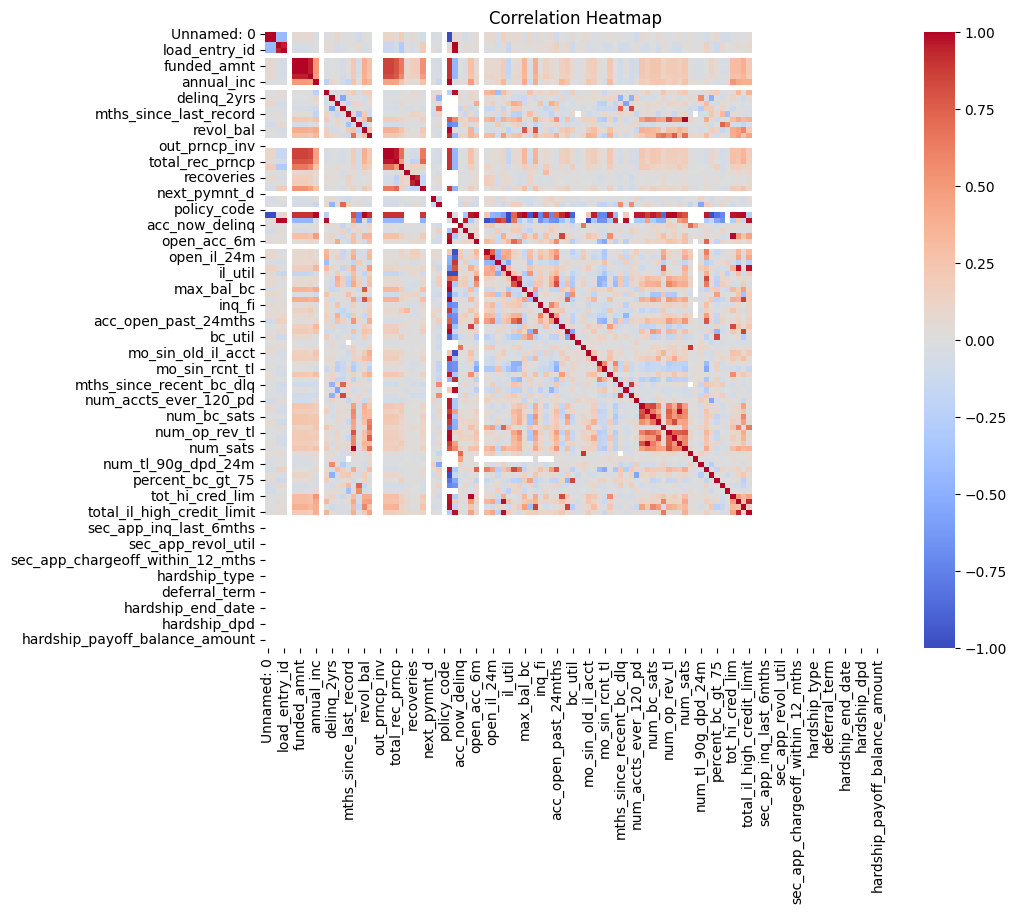

In [8]:
print("\n=== STEP 6: VISUALIZATIONS ===")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribution of numerical columns
for i, col in enumerate(numerical_cols[:4]):
    ax = axes[i//2, i%2]
    df[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('eda_numerical_distributions.png')
print("Saved: eda_numerical_distributions.png")

# Correlation heatmap (numerical only)
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
print("Saved: correlation_heatmap.png")


In [10]:
print("\n=== STEP 7: PREPROCESSING PIPELINE ===")

def preprocess_data(df):
    df_processed = df.copy()
    
    # 1. Handle missing values
    for col in df_processed.columns:
        if df_processed[col].dtype in ['int64', 'float64']:
            # df_processed[col].fillna(df_processed[col].median(), inplace=True)
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())
        else:
            df_processed[col] = df_processed[col].fillna('Unknown')
    
    # 2. Encode categorical variables
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
    
    return df_processed, label_encoders

df_clean, encoders = preprocess_data(df)
print(f"\nPreprocessed shape: {df_clean.shape}")
print(f"Missing values after preprocessing: {df_clean.isnull().sum().sum()}")


=== STEP 7: PREPROCESSING PIPELINE ===

Preprocessed shape: (1000, 141)
Missing values after preprocessing: 29000
